### Build A Basic Chatbot With Langgraph(Graph API Functionality)

In [3]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    messages:Annotated[list, add_messages]



In [5]:
import os
from dotenv import load_dotenv
load_dotenv()



True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

llm = ChatGroq(model="llama3-8b-8192")

##llm.invoke([HumanMessage(content="Hello")])


In [7]:
llm


ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F4C0DF5D30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F4C0DF6A50>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
## Node Functionality
def chatbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }


In [9]:
build_graph = StateGraph(State)

## Adding Node
build_graph.add_node("llmchatbot", chatbot)

## Ading Start Edge
build_graph.add_edge(START, "llmchatbot")
## Ading End Edge
build_graph.add_edge("llmchatbot", END)

## Compiling Graph
graph = build_graph.compile()

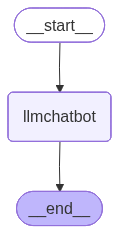

In [10]:
## Visualization of Graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:

from langchain_core.messages import HumanMessage

respone = graph.invoke({
    "messages": [HumanMessage(content="Hi")]
})



APIConnectionError: Connection error.

In [11]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

APIConnectionError: Connection error.

### Chatbot With Tools

In [27]:
from langchain_tavily  import TavilySearch

tool=TavilySearch(max_results=2)
response=tool.invoke("What is latest news of AI")

## Printing Response
for item in response["results"]:
    print(item["content"])
    print("-" * 80)

Explore the latest artificial intelligence news with Reuters - from AI breakthroughs and technology trends to regulation, ethics, business and global
--------------------------------------------------------------------------------
Google tests Remy AI agent for Gemini as focus turns to user control · Physical AI raises new governance questions for autonomous systems · Artificial
--------------------------------------------------------------------------------


In [14]:
### Custom Function

def multiply(a:int, b:int) -> int:
    """Multiply a and b

Args:
    a (int): first int
    b (int): second int

Returns:
    int: output int
"""
    return a*b

In [19]:
### Binding of Two tools with LLM Node
tools = [tool, multiply]

llm_with_tools=llm.bind_tools(tools)


In [20]:
llm_with_tools

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F4C0DF5D30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F4C0DF6A50>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-tim

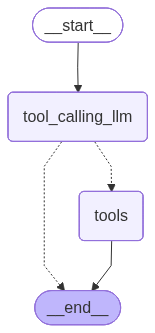

In [39]:
### StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Defination
def tool_calling_llm(state: State):
    return {
        "messages": [llm_with_tools.invoke(state["messages"])]
    }


## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))
